# GGIS 4381/6321 - Lab 2 - Data Wrangling and Pandas

**Authors:** Alexander Michels

This notebook is a quick crash course on how to perform basic data wrangling tasks using the [Pandas](https://pandas.pydata.org/docs/user_guide/index.html) package.

<hr id="pandas" />

## Intro to Pandas

[Pandas](https://pandas.pydata.org/docs/user_guide/index.html) is a key package for working with tabular (table-like) data in Python. There is also a geospatial version which we will explore in the next lab.


Pandas introduces two key classes (Python objects) for working with data:

* **Series:** a list (or *array*) of data of some type.
* **DataFrame:** a table-like data struction with rows and columns. The data within a DataFrame is sorted as Series.

In [2]:
import pandas as pd  # import and save it as an abbreviation

In [3]:
s = pd.Series([1, 2, 3, 4, 5])  # create a basic series
s  # print out the series

0    1
1    2
2    3
3    4
4    5
dtype: int64

In [4]:
s[0]  # you can *mostly* treat a series like a list, for example accessing by index

1

There are a LOT of ways to create a DataFrame by passing in data and a key benefit of using a well-established open-source package like this is that [there is plenty of documentation](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.html).

One way to do this is to create a *dictionary* of the column labels and data you want to include. For example:

In [5]:
data = {  # the brackets make a "dictionary" that saves key and value pairs
    'City': ["New York", "Dallas", "Los Angeles"],
    'State': ["New York", "Texas", "California"],
    '# of UTDs': [0, 1, 0]
}

data

{'City': ['New York', 'Dallas', 'Los Angeles'],
 'State': ['New York', 'Texas', 'California'],
 '# of UTDs': [0, 1, 0]}

We can access particular parts of the dictionary by giving the key (e.g., 'City').

In [6]:
data["City"]

['New York', 'Dallas', 'Los Angeles']

We can also use pandas to transform the data into a DataFrame (basically a table) using the "DataFrame" function from Pandas (which we saved as `pd`):

In [7]:
df = pd.DataFrame(data)
df

,City,State,# of UTDs
0,New York,New York,0
1,Dallas,Texas,1
2,Los Angeles,California,0


You'll notice that the DataFrame labeled each row with a number. This is called the `index` which is kind of the like the ID of the row. It allows us to refer to individual rows using the [`iloc`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.iloc.html#pandas.DataFrame.iloc) function.

In [8]:
print(type(df.iloc[1]))  # this returns a Series
df.iloc[1]

<class 'pandas.core.series.Series'>


City         Dallas
State         Texas
# of UTDs         1
Name: 1, dtype: object

We can similarly refer to columns using their name within brackets, like so:

In [9]:
df["State"]

0      New York
1         Texas
2    California
Name: State, dtype: object

If you want to view the whole DataFrame, you can just print it, but it is often more useful to only print the first few rows (especially for LONG dataframes). We can do this by calling the `head` function.

Here, we use `<object>.<function name>()` syntax because the `head` function is a *method* of the DataFrame object and not just a generic Python function. You sometimes need to keep track of:

* What are generic Python functions like `len` (that get called by `len(<arguments>)`
* What are functions from certain packages like `pd.DataFrame` (that get called by using the package name, dot, function name)
* What are *methods* that come from certain *Objects* (that get called by using `<object>.<method>`).

In [10]:
df.head()

,City,State,# of UTDs
0,New York,New York,0
1,Dallas,Texas,1
2,Los Angeles,California,0


You can also view how long a DataFrame is using `len` just like with lists.

In [11]:
len(df)  # we can get the length using `len` just like with lists!

3

For more information on Pandas, check out the [10 minutes to pandas](https://pandas.pydata.org/docs/user_guide/10min.html) guide.

<hr id="dwbasics" />

## Data Wrangling Basics

To work with real-life data, we can also load SpreadSheet data like Comma-Separated Values (CSV) files. If you look in the File Browser (right) for this folder, you should see a "TEXAS_COUNTY.csv" file. This file is the Texas county-level [Social Vulnerability Index (SVI)](https://www.atsdr.cdc.gov/place-health/php/svi/svi-data-documentation-download.html) data for 2022, calculated by the Centers for Disease Control (CDC). This data is used to assess how vulnerable communities are to environmental hazards like natural disasters or pandemics.

We can load the data using the pandas `read_csv` function. Note that this is a *pandas* function, so we need to use the following syntax:

In [12]:
svi = pd.read_csv("TEXAS_COUNTY.csv")  # load the CSV and save it using the svi variable
svi.head()  # let's see what we are working with!

,ST,STATE,ST_ABBR,STCNTY,COUNTY,FIPS,LOCATION,AREA_SQMI,E_TOTPOP,M_TOTPOP,...,EP_ASIAN,MP_ASIAN,EP_AIAN,MP_AIAN,EP_NHPI,MP_NHPI,EP_TWOMORE,MP_TWOMORE,EP_OTHERRACE,MP_OTHERRACE
0,48,Texas,TX,48001,Anderson County,48001,"Anderson County, Texas",1062.616344,58077,0,...,0.7,0.2,0.7,0.5,0.1,0.1,4.7,1.0,0.2,0.2
1,48,Texas,TX,48003,Andrews County,48003,"Andrews County, Texas",1500.720658,18362,0,...,0.5,0.2,0.0,0.3,0.0,0.3,0.8,0.7,0.1,0.1
2,48,Texas,TX,48005,Angelina County,48005,"Angelina County, Texas",797.864652,86608,0,...,0.9,0.1,0.4,0.4,0.0,0.1,3.6,0.9,0.2,0.2
3,48,Texas,TX,48007,Aransas County,48007,"Aransas County, Texas",252.068582,24048,0,...,1.7,1.3,0.5,0.3,0.0,0.2,2.2,1.1,0.0,0.2
4,48,Texas,TX,48009,Archer County,48009,"Archer County, Texas",903.288792,8649,0,...,0.2,0.2,0.4,0.2,0.0,0.6,3.1,0.6,0.0,0.1


### Quick Overviews

That's a lot of data and the ellipses (`...`) in the middle means we aren't seeing it all! Let's explore a few ways to get more info quickly:

In [13]:
print(list(svi.columns))  # we can print the column as a list to get all of them!

['ST', 'STATE', 'ST_ABBR', 'STCNTY', 'COUNTY', 'FIPS', 'LOCATION', 'AREA_SQMI', 'E_TOTPOP', 'M_TOTPOP', 'E_HU', 'M_HU', 'E_HH', 'M_HH', 'E_POV150', 'M_POV150', 'E_UNEMP', 'M_UNEMP', 'E_HBURD', 'M_HBURD', 'E_NOHSDP', 'M_NOHSDP', 'E_UNINSUR', 'M_UNINSUR', 'E_AGE65', 'M_AGE65', 'E_AGE17', 'M_AGE17', 'E_DISABL', 'M_DISABL', 'E_SNGPNT', 'M_SNGPNT', 'E_LIMENG', 'M_LIMENG', 'E_MINRTY', 'M_MINRTY', 'E_MUNIT', 'M_MUNIT', 'E_MOBILE', 'M_MOBILE', 'E_CROWD', 'M_CROWD', 'E_NOVEH', 'M_NOVEH', 'E_GROUPQ', 'M_GROUPQ', 'EP_POV150', 'MP_POV150', 'EP_UNEMP', 'MP_UNEMP', 'EP_HBURD', 'MP_HBURD', 'EP_NOHSDP', 'MP_NOHSDP', 'EP_UNINSUR', 'MP_UNINSUR', 'EP_AGE65', 'MP_AGE65', 'EP_AGE17', 'MP_AGE17', 'EP_DISABL', 'MP_DISABL', 'EP_SNGPNT', 'MP_SNGPNT', 'EP_LIMENG', 'MP_LIMENG', 'EP_MINRTY', 'MP_MINRTY', 'EP_MUNIT', 'MP_MUNIT', 'EP_MOBILE', 'MP_MOBILE', 'EP_CROWD', 'MP_CROWD', 'EP_NOVEH', 'MP_NOVEH', 'EP_GROUPQ', 'MP_GROUPQ', 'EPL_POV150', 'EPL_UNEMP', 'EPL_HBURD', 'EPL_NOHSDP', 'EPL_UNINSUR', 'SPL_THEME1', 'RPL_

In [14]:
svi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254 entries, 0 to 253
Columns: 158 entries, ST to MP_OTHERRACE
dtypes: float64(75), int64(79), object(4)
memory usage: 313.7+ KB


Another fun functionality is the `describe` method that provides quick statistics on the columns. 

If you aren't entirely sure of what that outputs mean, remember you always refer to the [documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html). Another option is Google or even AI, but it is always better to verify anything you get from random sites or AI just in case. 

In [15]:
svi.describe()

,ST,STCNTY,FIPS,AREA_SQMI,E_TOTPOP,M_TOTPOP,E_HU,M_HU,E_HH,M_HH,...,EP_ASIAN,MP_ASIAN,EP_AIAN,MP_AIAN,EP_NHPI,MP_NHPI,EP_TWOMORE,MP_TWOMORE,EP_OTHERRACE,MP_OTHERRACE
count,254.0,254.00000,254.00000,254.000000,2.540000e+02,254.000000,2.540000e+02,254.000000,2.540000e+02,254.000000,...,254.000000,254.000000,254.000000,254.000000,254.000000,254.000000,254.000000,254.000000,254.000000,254.000000
mean,48.0,48254.00000,48254.00000,1028.620655,1.151313e+05,17.456693,4.588571e+04,70.677165,4.130139e+04,380.976378,...,1.128346,0.788583,0.253150,0.809843,0.067323,1.051969,2.348819,1.256299,0.181102,1.048031
std,0.0,146.93536,146.93536,658.565040,4.106693e+05,55.635496,1.609053e+05,65.828605,1.481685e+05,435.239745,...,2.141567,1.734806,0.471867,2.850605,0.178695,3.523537,1.716250,3.238946,0.260201,3.513145
min,48.0,48001.00000,48001.00000,127.208705,9.600000e+01,0.000000,5.500000e+01,11.000000,3.800000e+01,25.000000,...,0.000000,0.100000,0.000000,0.100000,0.000000,0.100000,0.000000,0.100000,0.000000,0.100000
25%,48.0,48127.50000,48127.50000,835.680319,6.305500e+03,0.000000,2.798000e+03,27.250000,2.094000e+03,149.250000,...,0.200000,0.200000,0.100000,0.100000,0.000000,0.100000,1.400000,0.500000,0.000000,0.100000
50%,48.0,48254.00000,48254.00000,908.683707,1.838300e+04,0.000000,8.375000e+03,50.000000,6.594500e+03,259.000000,...,0.600000,0.200000,0.100000,0.200000,0.000000,0.300000,2.200000,0.800000,0.100000,0.300000
75%,48.0,48380.50000,48380.50000,1043.467704,5.242425e+04,0.000000,2.136875e+04,87.750000,1.801875e+04,442.750000,...,1.100000,0.600000,0.300000,0.475000,0.100000,0.700000,3.075000,1.100000,0.275000,0.700000
max,48.0,48507.00000,48507.00000,6183.760500,4.726177e+06,328.000000,1.851489e+06,485.000000,1.692896e+06,4042.000000,...,21.100000,20.500000,6.100000,37.500000,1.700000,37.500000,17.600000,37.500000,1.700000,37.500000


Pandas also has some basic visualization functionalities built-in including histograms:

<Axes: ylabel='Frequency'>

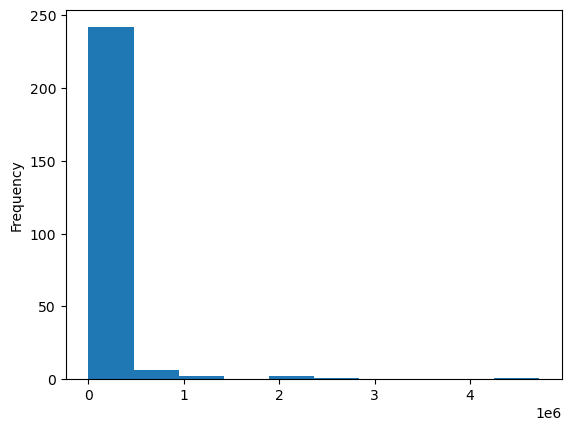

In [16]:
svi["E_TOTPOP"].plot.hist()  # plotting a histogram of the svi dataframe's "E_TOTPOP" (estimated population) column

### Basic Data Cleaning/Filtering

We will walk through a few basic steps to clean and filter data using Pandas. This will be useful when we move onto spatial data (GeoDataFrames) as it all uses DataFrames as a baseline.

We can create new columns or overwrite columns by using that bracket syntax we saw earlier to refer to columns. For example, let's say we want to work with population as thousands. The following code will create a new column called `PopDensity` and save the `E_TOTPOP` variable divided by `AREA_SQMI` variable as the result. It will automatically do this for every row and assign the correct values to each row.

In [17]:
svi["PopDensity"] = svi["E_TOTPOP"] / svi["AREA_SQMI"] 

<Axes: ylabel='Frequency'>

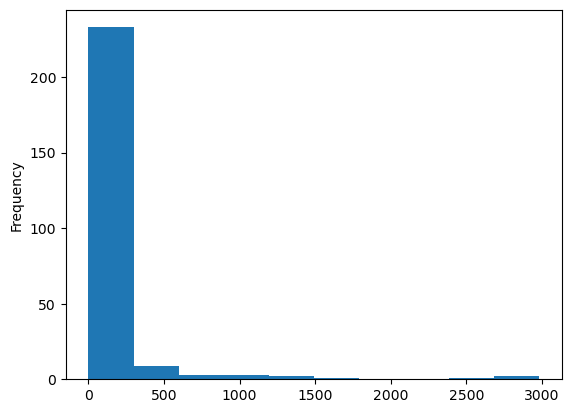

In [18]:
svi["PopDensity"].plot.hist()

If we want to delete that column, we can use the `drop` function and save the result. Note that just calling `svi.drop()` doesn't change the svi object, you need to assign svi to the result like so:

In [19]:
svi = svi.drop(columns=["PopDensity"])

In [20]:
svi["PopDensity"].plot.hist()  # this won't work because the column was dropped. You'll get a "KeyError" meaning that column name doesn't exist.

KeyError: 'PopDensity'

Another common task is filtering data! We can use the [`loc`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.loc.html#pandas.DataFrame.loc) method to filter our data down based on some criteria.

For example, below we filter the svi data to look for counties with a population over 1,000,000 (1 million, note you don't use the commas in the code). This will save the result in a new variable, so our `svi` dataset remains unaffected.

In [21]:
bigCounties = svi.loc[svi["E_TOTPOP"] > 1000000]

In [22]:
# this uses a fancy trick called "f-strings" to insert variables into the text we want to print!
print(f"There are {len(bigCounties)} counties with a population over 1,000,000! The svi dataset still has {len(svi)} rows though!")

There are 6 counties with a population over 1,000,000! The svi dataset still has 254 rows though!


## Self-Guided Exercises

A few exercises to help you test your knowledge and help you explore the documentation!

* Can you filter the svi dataframe by population (`E_TOTPOP`) above 1,000,000 but below 3,000,000?
* What county has the highest overall social vulnerability (refer to the documentation in this folder to see the variable name).
* What does the histogram look like for `AREA_SQMI`?
* How can you sort a dataframe using a column?

[Additional exercises for those interested](https://martinfleischmann.net/sds/data_wrangling/exercise.html)